# SOUMAP + MPEC Tutorial

This notebook demonstrates the full **SOUMAP → MPEC** workflow on a synthetic dataset
designed to make the results easy to interpret.

**Stages covered:**
1. Background: what SOUMAP does and why
2. Generate data
3. Configure and train SOUMAP
4. Inspect the SOUMAP embedding (before and after training)
5. Run MPEC clustering on the SOUMAP outputs
6. Interpret the MPEC diagnostic plots

**Data:** `sklearn.make_blobs`, N=5000, D=10, K=5 clusters, `cluster_std=1.5`
(moderate overlap — not trivially separable).

---
## 1. Background

### Self-Organizing Maps

A **Self-Organizing Map (SOM)** is an unsupervised neural network that learns a
compressed, topology-preserving representation of high-dimensional data. Training
places a fixed set of *M* prototype vectors **W** into the data space such that
nearby prototypes in the *output space* respond to nearby regions of the *input
space*. At each training step, the closest prototype to a data point (the
*best-matching unit*, or BMU) and its output-space neighbors are nudged toward
that point. The neighborhood bandwidth shrinks across training, so the map
progressively refines its representation of the data.

In a classical SOM the output-space topology is a fixed rectangular or hexagonal
grid chosen before training begins — it has nothing to do with the data itself.
**GTSOM** ([`gtsom`](https://github.com/jt-ut/gtsom)) removes this constraint:
prototypes are seeded by a low-dimensional projection of the data (e.g. PCA), and
the adjacency graph is constructed from those projected positions (Gabriel graph
or Delaunay triangulation). The topology therefore *reflects the data geometry*
from the very first training step.

### UMAP

**UMAP** (Uniform Manifold Approximation and Projection) is a dimensionality
reduction algorithm that models the data manifold and finds a low-dimensional
layout that preserves its topological structure. Unlike PCA, UMAP captures
non-linear relationships and tends to produce tight, well-separated clusters when
they exist in the data. The key user-controlled parameters are `n_neighbors`
(controls how local vs. global the view is) and `min_dist` (controls how tightly
points are packed in the embedding).

### SOUMAP: the hybrid

**SOUMAP** alternates between a SOM step and a UMAP step, coupling the two
algorithms so that each informs the other:

- **SOM step** — prototype vectors **W** are updated by batch SOM learning. The
  output-space topology used to define neighborhoods is derived from a Gabriel
  graph (or Delaunay triangulation) of the *current embedding coordinates* **Y**.
- **UMAP step** — a UMAP similarity graph is built from the *co-adjacency matrix*
  (CADJ) produced by VQ recall. The UMAP layout optimizer updates **Y**,
  warm-started from its current state. The new **Y** becomes the SOM's output
  topology for the next SOM step.

Two key differences from the standard versions:
- Unlike a classical SOM, the output lattice is **not fixed** — it evolves with
  the data structure.
- Unlike standard UMAP, the similarity graph is **not user-prescribed** — it is
  inferred from the learned VQ topology, so there is no `n_neighbors` parameter
  to tune.

The result is a set of *M* prototype vectors that tile the data density, together
with a 2-D embedding of those prototypes that faithfully reflects their
high-dimensional geometry.

### MPEC: from embedding to clustering

Once SOUMAP has been trained it yields three complementary views of the prototype
space:

| View | What it captures |
|------|------------------|
| **CADJ** | Density + topology — a count matrix recording how many data points fall in the second-order Voronoi cells shared by each prototype pair, encoding both local density and high-D topology |
| **W** | High-D geometry — Euclidean proximity in feature space |
| **Y** | Low-D geometry — Euclidean proximity in the embedding |

**MPEC** (Multiview Prototype Embedding & Clustering) fuses these three views
into a single weighted graph using self-tuning kernels, then partitions the graph
with the **Walktrap** community-detection algorithm (Pons & Latapy, 2005). The
number of random-walk steps is found automatically by analyzing the tradeoff
between Markov-chain mixing and cluster cohesion across steps.

---
## 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

from soumap import SOUMAP, SOMParams, UMAPParams, CtrlParams, MPEClustering

---
## 3. Generate data

We use `sklearn.make_blobs` to generate 5 Gaussian clusters in 10 dimensions
with 5,000 total samples. `cluster_std=1.5` gives moderate overlap — the clusters
are not trivially separable, making this a good stress-test for the algorithm.

In [2]:
N, D, K, M = 5000, 10, 5, 100

X, y_true = make_blobs(
    n_samples=N,
    n_features=D,
    centers=K,
    cluster_std=1.5,
    random_state=42,
)
print(f"X: {X.shape}")
print(f"Ground-truth classes: {np.unique(y_true)}")

X: (5000, 10)
Ground-truth classes: [0 1 2 3 4]


---
## 4. Configure and train SOUMAP

SOUMAP is configured via three parameter dataclasses:

- **`SOMParams`** — controls the SOM learning dynamics (neighborhood bandwidth
  schedule, output-space topology type, prototype topology).
- **`UMAPParams`** — controls the UMAP layout optimizer (update frequency,
  number of epochs, `min_dist` and `spread` schedules, learning rate schedule).
- **`CtrlParams`** — controls the overall training loop (total epochs,
  initialization strategy, random seed, verbosity).

After construction, `tune_embed_scale()` calibrates `rho_0`, `min_dist_0`, and
`spread_0` from the null geometry of the data — this step sets the initial
neighborhood and embedding scales to sensible values without manual tuning.

`build()` initializes the prototype vectors and embedding coordinates; `fit()`
runs the alternating SOM/UMAP training loop.

Note that we use `coord_init='random'` here so that the prototypes start in a
completely unorganized state. This makes the learning that SOUMAP performs more
apparent when comparing the initial and final embeddings.

In [3]:
som_params = SOMParams(
    rho_0=2.0,             # overwritten by tune_embed_scale()
    rho_f=0.5,
    nbr_topo_alpha_0=0.5,
    nbr_topo_alpha_f=1.0,
    coord_topo='gabriel',
    proto_topo='STK_CADJ',
    compute_dr_metrics=False,
)

umap_params = UMAPParams(
    update_freq=5,
    n_epochs=100,
    min_dist_0=0.1,        # overwritten by tune_embed_scale()
    min_dist_f=0.1,
    spread_0=2.0,          # overwritten by tune_embed_scale()
    spread_f=2.0,
    lrate_0=1.0,
    lrate_f=0.5,
    negative_sample_rate=5,
    gamma=1.0,
    use_standard_umap=False,
)

ctrl_params = CtrlParams(
    total_epochs=100,
    min_nhbs=3,
    fill_val=1,
    coord_init='random',   # random init makes the learned organization more apparent
    embedding_range=(-3.0, 3.0),
    n_jobs=1,              # sequential = reproducible
    random_state=42,
    verbose=True,
    plot_every=0,
)

model = SOUMAP(
    M=M,
    som_params=som_params,
    umap_params=umap_params,
    ctrl_params=ctrl_params,
)

print("Tuning embedding scale parameters...")
model.tune_embed_scale(rho0_scale=0.75, min_dist0_scale=1.0, min_distf_scale=0.1)
print(f"  rho_0      = {model.som_params.rho_0:.4f}")
print(f"  min_dist_0 = {model.umap_params.min_dist_0:.4f}")
print(f"  spread_0   = {model.umap_params.spread_0:.4f}")

print("\nBuilding SOUMAP architecture...")
model.build(X, labels=y_true)

Tuning embedding scale parameters...
tune_embed_scale: null_max_geo_dist=8.0000, null_mean_geo_dist=4.2364, null_mean_edge_len=0.7208 | rho_0=6.0000, min_dist_0=0.7208, spread_0=2.0000
  rho_0      = 6.0000
  min_dist_0 = 0.7208
  spread_0   = 2.0000

Building SOUMAP architecture...
Running FAISS k-means with 100 clusters (niter=20, nredo=1)...
K-means complete. Final MQE: 13.534280
Fitting complete using kmeans method.


SOUMAP(M=100, total_epochs=100, age=0)

### Initialization (age = 0)

Before training begins, prototype embedding coordinates are assigned randomly.
The prototypes are scattered with no organization — cluster labels are mixed
throughout the embedding, and the Gabriel graph edges cross freely between
groups. There is no correspondence yet between position in the 2-D output space
and identity in the 10-D feature space.

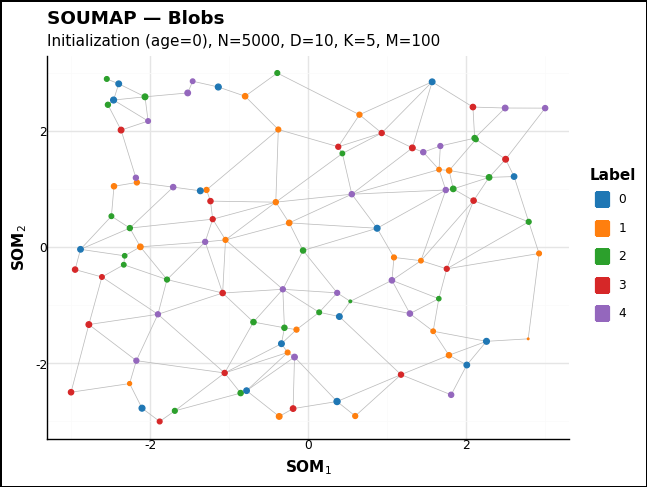

In [4]:
g_init = model.gtsom.plot(
    color_by='labels',
    title='SOUMAP — Blobs',
    subtitle=f'Initialization (age=0), N={N}, D={D}, K={K}, M={M}',
)
g_init.draw()

In [5]:
print("Fitting SOUMAP (100 epochs)...")
model.fit(X, labels=y_true)
print(f"Done. age={model.age}")

Fitting SOUMAP (100 epochs)...
  Epoch      rho    alpha        MQE    delBMU
  -----   ------   ------   --------   -------
      1   6.0000   0.5000    12.2412    0.9448
      2   5.8527   0.5035    10.6174    1.0000
      3   5.7091   0.5070     9.8206    0.8792
      4   5.5690   0.5105     8.9584    0.7988
      5   5.4323   0.5141     9.2314    0.6322
  -----   ------   ------   --------   -------
  PCADJ: min_nnz=3, max_nnz=4, mean_nnz=3.0, empty_rows=0, below_min_nhbs=0
  FSIM:  min_nnz=3, max_nnz=6, mean_nnz=3.7, val_range=[0.006, 1.000]
  UMAP update  age=5  rho=5.2990  alpha=0.5176  lrate=0.9659  min_dist=0.6424
  Epoch      rho    alpha        MQE    delBMU
  -----   ------   ------   --------   -------
      6   5.2990   0.5176     6.3456    0.9330
      7   5.1689   0.5212     5.7385    0.9632
      8   5.0421   0.5249     5.8442    0.9550
      9   4.9183   0.5285     5.5923    0.8762
     10   4.7976   0.5322     5.6757    0.5324
  -----   ------   ------   --------   -

### After training (age = 100)

After 100 training epochs the five clusters are tightly packed and clearly
separated in the embedding. The inter-cluster edges have disappeared: the
Gabriel graph now connects only prototypes within the same cluster. Each cluster
occupies a compact, internally connected region of the 2-D output space,
and the relative positions of the clusters faithfully reflect their separation
in the original 10-D feature space. The contrast with the random initialization
above illustrates how much organization SOUMAP learns jointly across the SOM
and UMAP steps.

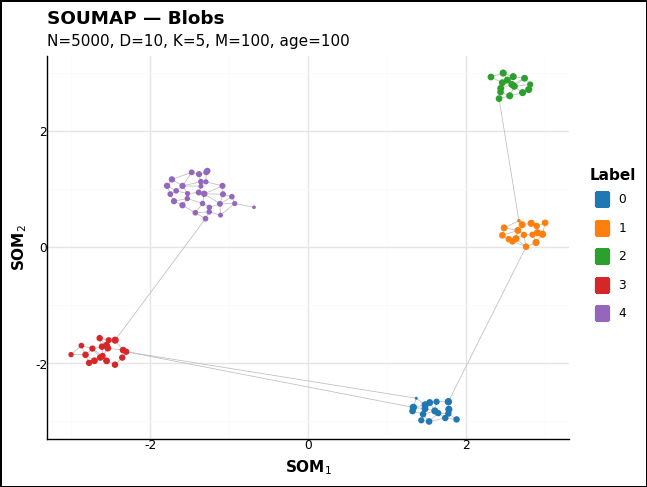

In [6]:
g_final = model.gtsom.plot(
    color_by='labels',
    title='SOUMAP — Blobs',
    subtitle=f'N={N}, D={D}, K={K}, M={M}, age={model.age}',
)
g_final.draw()

---
## 5. Save and reload SOUMAP

Models can be saved to HDF5 and reloaded, preserving all prototype vectors,
embedding coordinates, and learned topology.

In [7]:
model.save('blobs_soumap.h5')
model = SOUMAP.load('blobs_soumap.h5')
print(f"Reloaded: age={model.age}, W={model.W.shape}, coords={model.coords.shape}")

Reloaded: age=100, W=(100, 10), coords=(100, 2)


---
## 6. Run MPEC clustering

MPEC takes three inputs directly from the trained SOUMAP:

- **W** — the prototype vectors (high-D view)
- **Y** (`model.coords`) — the 2-D embedding coordinates (low-D view)
- **CADJ** — the Cumulative Adjacency Matrix (Tasdemir & Merenyi, 2009).
  CADJ[i,j] counts the number of data points that fall in the second-order
  Voronoi cell shared by prototypes *i* and *j* — i.e. points for which *i*
  and *j* are the first and second BMU, or vice versa. Because its entries are
  counts rather than binary flags, CADJ encodes both high-D topology (which
  prototypes are adjacent in data space) and an unnormalized view of local
  density (how many data points lie in the shared region between them).

These are fused into a single weighted graph via self-tuning kernels, then
Walktrap community detection partitions the graph into clusters.

With `walktrap_n_steps="auto"`, MPEC analyzes the mixing/cohesion tradeoff
across walk lengths to select the optimal step count automatically.

In [8]:
W         = model.W
Y         = model.coords
CADJ      = model.gtsom.recaller.CADJ
CADJ_nhbs = model.gtsom.recaller.CADJ_nhbs

mpec = MPEClustering(
    walktrap_n_steps="auto",
    kernel_w_cadj=1.0,
    kernel_w_high_d=1.0,
    kernel_w_low_d=1.0,
    kernel_power=2.0,
    verbose=True,
)

mpec.fit(W=W, Y=Y, CADJ=CADJ, CADJ_nhbs=CADJ_nhbs)

n_clusters = len(np.unique(mpec.active_labels_))
print(f"\nGround-truth K = {K}")
print(f"MPEC found    = {n_clusters} clusters")
print(f"Walktrap steps used: {mpec.n_steps_}")

[MPEClustering] Starting fit: M=100 prototypes, W.shape=(100, 10), Y.shape=(100, 2)
[MPEClustering] Found 3/100 empty prototypes (3.0%).
[MPEClustering] Clustering 97 active prototypes.
[MPEClustering] 2 prototype(s) have fewer than 3 CADJ neighbours after subsetting. CADJ_self_tuning_kernel will pad internally for the Euclidean views; kernel_cadj_ is left unpadded so genuine low-density rows remain visible in the fused graph.
[MPEClustering] Building high-D Euclidean kernel view...
[MPEClustering] Building low-D Euclidean kernel view...
[MPEClustering] Fusing views into weighted graph...
[MPEClustering] Fused graph: 97 vertices, 1014 edges (density=0.216).
[MPEClustering] Finding optimal Walktrap step count...
[MPEClustering] Step analysis: 4 communicating class(es), sizes: [33, 30, 19, 15]
[MPEClustering] Component 0 (size=33): CC(1)=0.9925, HD(1)=0.6336
[MPEClustering] Component 0 (size=33): crossing at step=3 (cc_norm=1.0000, hd_norm=0.8668)
[MPEClustering] Component 1 (size=30): C

---
## 7. MPEC diagnostic plots

MPEC provides six diagnostic plots, each illuminating a different aspect of the
clustering process. They are generated and described individually below.

### 7.1 Walktrap step tradeoff

Walktrap partitions a graph by simulating short random walks and inferring that
nodes frequently visited together belong to the same community. The length of
those walks — the number of steps *t* — is a critical choice. Pons & Latapy
offered intuitive guidance: we want to iterate the Markov chain long enough that
intra-cluster structure becomes apparent, but not so long that the chain
approaches its stationary distribution, at which point all memory of where the
walk started is lost and community structure disappears.

MPEC operationalizes this tradeoff by tracking two normalized quantities as *t*
increases:

- **Transience (TR)** — the normalized Hellinger distance of the transition
  matrix rows from the stationary distribution. TR = 1 at step 1 (the chain is
  fully transient) and decreases monotonically toward 0 as the walk mixes.
  High TR means the walker still "remembers" where it started — community
  information is preserved.
- **Cluster Cohesion (CC)** — the normalized gain in the Barrat weighted
  clustering coefficient since step 1. CC starts at 0 and rises as the
  multi-step transition probabilities concentrate within clusters, making
  intra-cluster triangles more prominent in the walk graph.

The optimal step is the **first crossing point** — the first *t* where `CC ≥ TR`.
At this point, the cohesion gain has caught up with the transience loss: the walk
has run long enough to reveal cluster structure, but not so long that the
stationary distribution has erased it. The dashed vertical line marks the
selected step.

On the blobs data, step 1 is selected for all components, indicating that the
fused graph already has such strong community structure that even a single-step
walk is sufficient for Walktrap to find the correct partition.

[MPEClustering] Rendering: step_tradeoff...


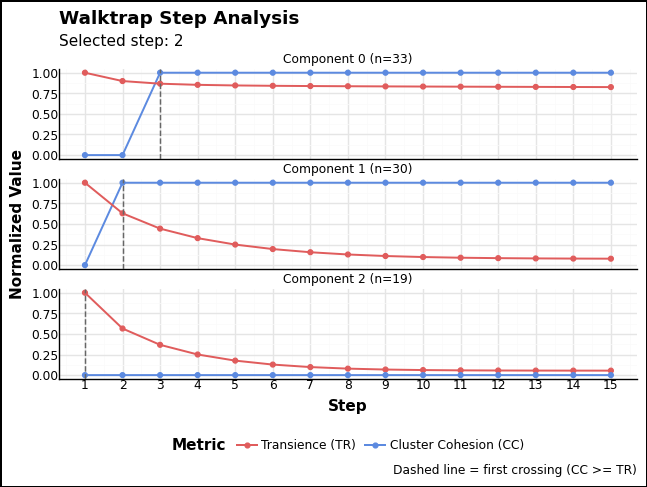

In [9]:
panel = mpec.plot_diagnostics(which=["step_tradeoff"], figsize=(6, 5))
panel["step_tradeoff"].draw()

### 7.2 Kernel edge weight distributions

Distributions of edge weights in each of the three kernel views (CADJ, High-D,
Low-D) after self-tuning normalization. On the blobs data, all three views
produce bimodal distributions with a peak near 0 (weak inter-cluster edges) and
a peak near 1 (strong intra-cluster edges), confirming that the cluster structure
is cleanly captured by every view.

[MPEClustering] Rendering: edge_distributions...


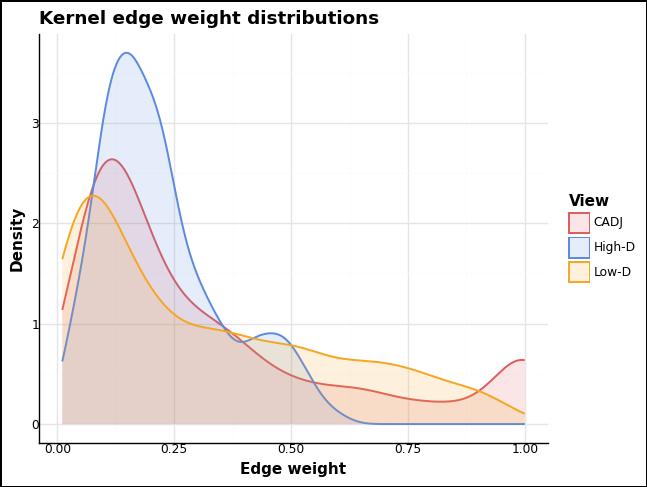

In [10]:
panel = mpec.plot_diagnostics(which=["edge_distributions"], figsize=(6, 5))
panel["edge_distributions"].draw()

### 7.3 Modularity curve

Walktrap modularity as a function of the number of clusters *k*, across the full
dendrogram. The optimal cut is the *k* that maximizes modularity within the valid
range shown in the subtitle. On the blobs data, modularity peaks sharply at
*k* = 5, exactly matching the ground-truth number of clusters.

[MPEClustering] Rendering: modularity...


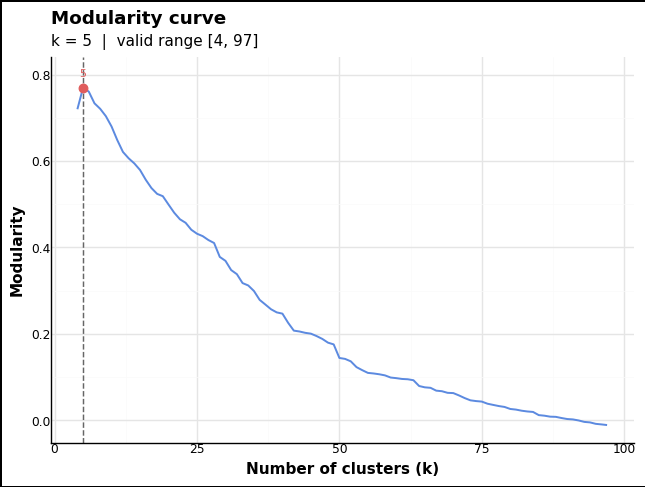

In [11]:
panel = mpec.plot_diagnostics(which=["modularity"], figsize=(6, 5))
panel["modularity"].draw()

### 7.4 Cluster sizes

Number of active prototypes assigned to each cluster; the dashed line marks the
mean. On the blobs data, clusters are roughly balanced (~19–20 prototypes each),
reflecting the balanced ground-truth class sizes.

[MPEClustering] Rendering: cluster_sizes...


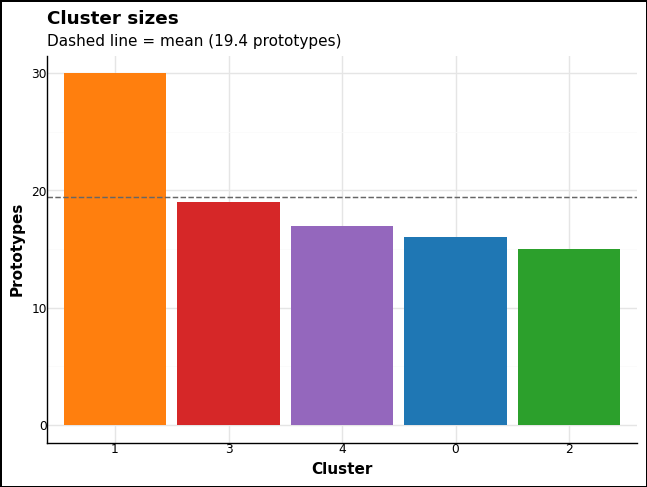

In [12]:
panel = mpec.plot_diagnostics(which=["cluster_sizes"], figsize=(6, 5))
panel["cluster_sizes"].draw()

### 7.5 Embedding with cluster colors

The SOUMAP embedding colored by MPEC cluster assignment, with fused graph edges
overlaid. Each of the five clusters occupies a distinct, compact region of the
2-D space. No inter-cluster edges appear, confirming that the Walktrap cut
correctly partitions the five groups.

[MPEClustering] Rendering: embedding...


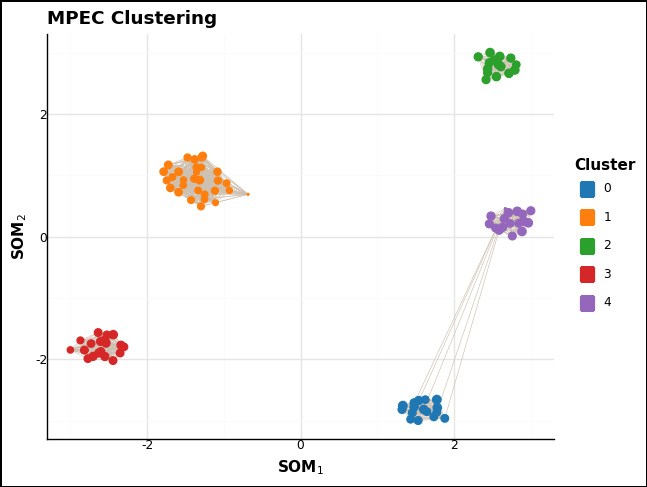

In [13]:
panel = mpec.plot_diagnostics(
    embed_coords=Y,
    show_graph=True,
    which=["embedding"],
    point_size=3.0,
    figsize=(6, 5),
)
panel["embedding"].draw()

### 7.6 Kernel view agreement

A 3×3 heatmap of Frobenius cosine similarity between each pair of kernel views.
High agreement (near 1.0) means two views encode similar structure; lower values
mean they contribute complementary information. On the blobs data, the High-D
and Low-D views agree most strongly (0.85) — expected, since both capture
Euclidean proximity and the SOUMAP embedding faithfully reflects feature-space
geometry. The CADJ view agrees moderately with each (0.56–0.62), reflecting that
its density-weighted topology encodes a subtly different aspect of the prototype
relationships than pure geometric distance.

[MPEClustering] Rendering: view_agreement...


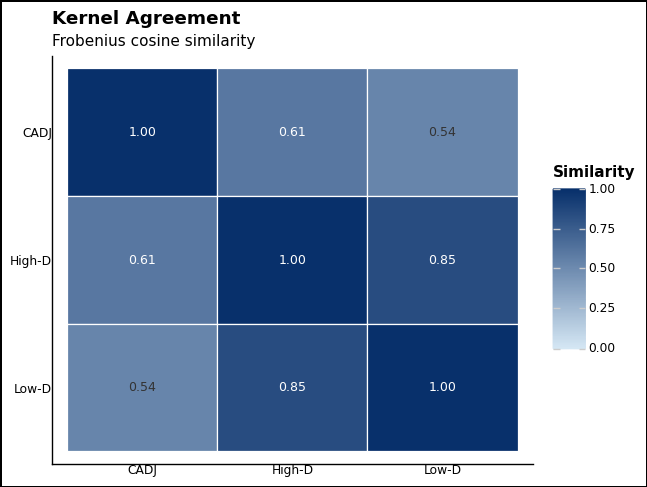

In [14]:
panel = mpec.plot_diagnostics(which=["view_agreement"], figsize=(6, 5))
panel["view_agreement"].draw()

---
## 8. Summary

In this tutorial we trained SOUMAP on a synthetic 10-D dataset with 5 moderately
overlapping Gaussian clusters and then applied MPEC to recover those clusters
from the learned prototype representation.

**Key takeaways:**

- SOUMAP jointly learns *M* prototype vectors and their 2-D embedding, with the
  embedding topology evolving during training rather than being fixed in advance.
  Starting from a random initialization makes the degree of learned organization
  clearly visible.
- After training, the embedding clearly separates the five clusters even though
  they overlap in the original 10-D space.
- MPEC fuses three complementary views of the prototype space — CADJ
  (density + topology), high-D geometry, and low-D geometry — and recovers
  the correct number of clusters without requiring *k* to be specified by the user.
- The six diagnostic plots provide insight into the clustering process: the
  step-tradeoff plot explains the walk-length selection, the modularity curve
  shows the evidence for the chosen *k*, and the embedding plot gives an
  interpretable view of the result.

**Next steps:**
- Apply the pipeline to real data (e.g. MNIST handwritten digits — see
  `test_mnist.py` in the repository).
- Experiment with `kernel_power` and the per-view weights to emphasize
  different aspects of the prototype structure.
- Use `model.transform(X_new)` to map new data points to the learned embedding.